
## Estudio de caso: Par Inc

Par Inc., es un importante fabricante de equipos de golf.

La gerencia cree que la participación de mercado de Par <b>podría incrementarse con la introducción de una pelota de golf <u>resistente a los cortes</u> y de <u>mayor duración</u></b>. Por lo tanto, el grupo de investigación de Par ha estado investigando un nuevo revestimiento de pelota de golf diseñado para resistir cortes y proporcionar una pelota más duradera.

Las pruebas con el revestimiento han sido prometedoras. Uno de los investigadores <b>expresó su preocupación por el efecto del nuevo revestimiento en las distancias de conducción</b>. A Par le gustaría que la nueva pelota resistente a los cortes <b>ofreciera distancias de conducción <u>comparables a las del modelo actual</u> de pelota de golf</b>.

Para comparar las distancias de conducción de las dos bolas, se sometieron a pruebas de distancia <b>40 bolas de los modelos nuevo y actual</b>.

La prueba se realizó con una máquina mecánica, de modo que cualquier <u>diferencia entre las distancias medias de los dos modelos pudiera atribuirse a una diferencia en el diseño</u>.

Los resultados de las pruebas, con distancias medidas a la yarda más cercana, están contenidos en el conjunto de datos “Golf”.

### Preguntas:

1. Formular y presentar la justificación de un test de hipótesis que Par podría usar para comparar las distancias de conducción de las pelotas de golf actuales y nuevas.


2. Analizar los datos para proporcionar la conclusión del test de hipótesis.
    ¿Cuál es el p valor de la prueba?
    ¿Cuál es la recomendación para Par Inc.?


3. Proporcionar resúmenes estadísticos descriptivos de los datos para cada modelo.


4. ¿Cuál es el intervalo de confianza del 95% para la media poblacional de cada modelo y cuál es el intervalo de confianza del 95% para la diferencia entre las medias de las dos poblaciones?


5. ¿Vemos la necesidad de tamaños de muestra más grandes y más pruebas con las pelotas de golf?### Preguntas:

1. Formular y presentar la justificación de un test de hipótesis que Par podría usar para comparar las distancias de conducción de las pelotas de golf actuales y nuevas.


2. Analizar los datos para proporcionar la conclusión del test de hipótesis.
    ¿Cuál es el p valor de la prueba?
    ¿Cuál es la recomendación para Par Inc.?


3. Proporcionar resúmenes estadísticos descriptivos de los datos para cada modelo.


4. ¿Cuál es el intervalo de confianza del 95% para la media poblacional de cada modelo y cuál es el intervalo de confianza del 95% para la diferencia entre las medias de las dos poblaciones?


5. ¿Vemos la necesidad de tamaños de muestra más grandes y más pruebas con las pelotas de golf?

### Objetivo del Proyecto:

El objetivo del informe es explorar el conjunto de datos de Par Inc. ("Golf") en R y generar información sobre el conjunto de datos.


- Importar el conjunto de datos en R (Vamos a utilizar Python)
- Comprender la estructura del conjunto de datos
- Exploración gráfica
- Estadísticas descriptivas
- Insights del conjunto de datos

### Supuestos

Suponemos que el nivel de aceptación del cambio en la distancia de conducción de <b>5 yardas</b> es aceptable para calcular los errores de Tipo I Tipo II y el tamaño de muestra requerido.

La máquina que se utiliza para impulsar las bolas es la misma, por lo que podemos suponer que la fuerza implícita en las bolas es igual en ambos casos.

Suponemos que el flujo de aire durante la prueba es uniforme y no tiene ningún efecto sobre el cambio en las distancias de conducción.

### Exploratory Data Analysis

Cargemos la data primero que nada

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('./data/Fichero Golf.csv', sep=',')

# Shape of the data
print("the shape of data is (n,m):", data.shape)

# Names of columns
print("the names of columns are:", data.columns)

the shape of data is (n,m): (40, 2)
the names of columns are: Index(['Current', 'New'], dtype='object')


Veamos ahora un poco las metricas base de cada columna

In [3]:
# Describe data
data.describe()

,Current,New
count,40.000000,40.000000
mean,270.275000,267.500000
std,8.752985,9.896904
min,255.000000,250.000000
25%,263.000000,262.000000
50%,270.000000,265.000000
75%,275.250000,274.500000
max,289.000000,289.000000


Podemos ver una desviación estandard en el actual de 8.52 y el nuevo d 9.89

In [4]:
print("SD for Variable Current: ", data['Current'].std())
print("SD for Variable New: ", data['New'].std())

SD for Variable Current:  8.752984838884595
SD for Variable New:  9.896904462947894


In [5]:
print("The variance for Variable Current: ", data['Current'].var())
print("The variance for Variable New: ", data['New'].var())

The variance for Variable Current:  76.61474358974358
The variance for Variable New:  97.94871794871794


In [6]:
print("SD difference between New And Current: ", (data['New'] - data['Current']).std())

SD difference between New And Current:  13.74397303809182


Ahora vamos a visualizar las distribuciones de ambas columnas, para ello usaremos Matplotlib y Seaborn

In [7]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

Text(0.5, 1.0, 'Boxplot for New Variable')

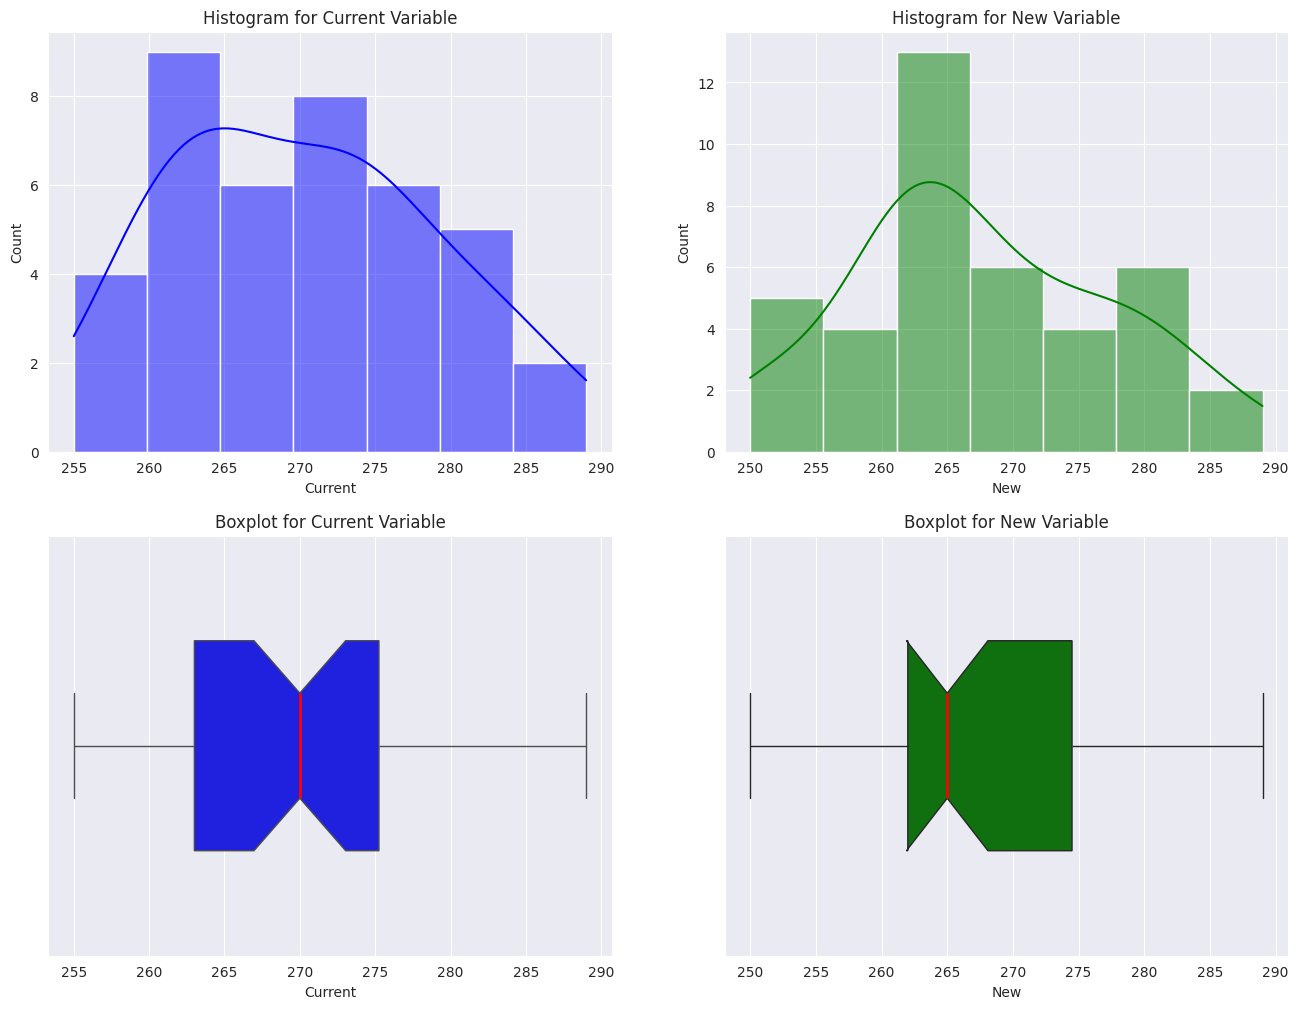

In [8]:
# Set canva size with 2 columns and 2 rows
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(16,12))

# Plot Histograms for Current and New variables
sns.histplot(data['Current'], ax=ax[0][0], kde=True, color='blue')
ax[0][0].set_title('Histogram for Current Variable')

sns.histplot(data['New'], ax=ax[0][1], kde=True, color='green')
ax[0][1].set_title('Histogram for New Variable')

# Plot Boxplots for Current and New variables
sns.boxplot(data['Current'], ax=ax[1][0], color='blue', orient='h', width=0.5, notch = True,
    medianprops = dict(color='red', linewidth=2)
)
ax[1][0].set_title('Boxplot for Current Variable')

sns.boxplot(data['New'], ax=ax[1][1], color='green', orient='h', width=0.5, notch = True, 
    medianprops = dict(color='red', linewidth=2)
)
ax[1][1].set_title('Boxplot for New Variable')


Podemos ver que ambas variables tienen una distribución con tendencia a parecer **normal**,  pero la variable <i>Current</i> está **sesgada a la izquierda (asímetría positiva)** y <i>New</i> está **sesgada a la derecha (asimetría negativa)**.

Por otro lado, no se observan valores atípicos.

Para ubicar los valores atíticos de las distribuciones, basta con realizar un proceso de validacion con IQR. Por tanto, creamos una función y etiquetamos para encontrar valores atipicos de haberlos.

In [9]:
def get_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

data['Current_outliers'] = get_outliers_iqr(data, 'Current')['Current']
data['New_outliers'] = get_outliers_iqr(data, 'New')['New']

print("Outliers for current variable: ", data['Current_outliers'].dropna().values)
print("Outliers for new variable: ", data['New_outliers'].dropna().values)

Outliers for current variable:  []
Outliers for new variable:  []


No parece haber valores atípicos en las distribución, por tanto podemos continuar sin descartar valores.

#### Observaciones generales

1. Sample size: 40
2. Número de muestras: 2
3. Variables no pareadas
4. DOF (Degrees of Freedom) = 40 + 40 - 2 = 78
5. No hay valores atípicos en los datos ni missing values
6. Ambas muestras parecen estar distribuidas normalmente, sin un sesgo demasiado grande
7. Valores medios y medianos no son muy diferentes
8. Los datos de la distancia de conducción actual tiene una distribucion normal, mientras que las distancias de la conducción de las bolas nuevas parecen estar sesgados a la derecha.

In [10]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(data['Current'], data['New'], alternative = 'two-sided')

t_stat, p_value

(1.2769699827911767, 0.20916361823147053)

In [12]:
res = stats.ttest_ind(data['Current'], data['New'], alternative = 'two-sided', equal_var = False)

print("T-statistic: ", res.statistic)
print("P-value: ", res.pvalue)
print("Degrees of freedom: ", res.df)
print("95% confidence interval: ", res.confidence_interval())

T-statistic:  1.3283615935245678
P-value:  0.18798994530489838
Degrees of freedom:  76.8521298692983
95% confidence interval:  ConfidenceInterval(low=-1.3849370620449646, high=6.934937062044919)
